In [186]:
import pandas as pd
import time
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import fpgrowth, apriori
from mlxtend.preprocessing import TransactionEncoder
from PAMI.frequentPattern.basic import ECLAT

## Подготовка данных

In [ ]:
def load_data(filename):
    """
    Загружает данные из .csv файла и преобразует их в список транзакций
    
    :params:
    filename -- имя csv-файла с покупками
    
    :returns:
    transactions -- список товаров в каждой транзакции
    """
    data = pd.read_csv(filename, header=None, encoding='cp1251')
    # Преобразуем строки в списки товаров
    transactions = data.apply(lambda row: [item.strip() for item in row.dropna()], axis=1)
    
    return transactions

def prepare_data_for_mlxtend(transactions):
    """
    Подготавливает данные для использования с mlxtend
    
    :params:
    transactions -- список транзакций
    
    :returns:
    df -- DataFrame в формате one-hot encoding
    """
    transaction_list = transactions.tolist()
    
    # Используем TransactionEncoder для создания one-hot encoding
    te = TransactionEncoder()
    te_ary = te.fit(transaction_list).transform(transaction_list)
    df = pd.DataFrame(te_ary, columns=te.columns_)
    
    return df

def prepare_data_for_eclat(transactions):
    """
    Подготавливает данные для pyECLAT
    
    :params:
    transactions -- список списков
    
    :returns:
    DataFrame, где каждый столбец — позиция товара в транзакции
    """
    df = pd.DataFrame(transactions.tolist())
    df_eclat = pd.DataFrame({
        "Transactions": df.apply(
            lambda row: "\t".join(str(item) for item in row if pd.notna(item)),
            axis=1
        )
    })
    return df_eclat


In [188]:
# Загружаем данные
data_path = "./baskets.csv"
transactions = load_data(data_path)
print(f"Загружено {len(transactions)} транзакций. Пример данных:")
print(transactions.head())

# Подготавливаем данные для mlxtend
df_encoded = prepare_data_for_mlxtend(transactions)
print(f"\nПодготовлено {df_encoded.shape[0]} транзакций с {df_encoded.shape[1]} уникальными товарами")

# Подготавливаем для ECLAT
df_eclat = prepare_data_for_eclat(transactions)

Загружено 7501 транзакций. Пример данных:
0    [креветки, миндаль, авокадо, овощная смесь, зе...
1                       [гамбургер, фрикадельки, яйца]
2                                              [чатни]
3                                   [индейка, авокадо]
4    [минеральная вода, молоко, энергетический бато...
dtype: object

Подготовлено 7501 транзакций с 115 уникальными товарами


## Поиск частых наборов

In [ ]:
def run_apriori(df, min_support, sort_method="support"):
    """
    Выполняет алгоритм apriori из mlxtend
    
    :params:
    df -- DataFrame в формате one-hot encoding
    min_support -- минимальный порог поддержки
    
    :returns:
    DataFrame с найденными частыми наборами
    """
    start_time = time.time()
    frequent_itemsets = apriori(df, min_support=min_support, use_colnames=True)
    execution_time = time.time()-start_time

    # Преобразуем frozenset в tuple для совместимости
    frequent_itemsets['itemsets'] = frequent_itemsets['itemsets'].apply(lambda x: tuple(x))
    
    if sort_method == "support":
        frequent_itemsets = frequent_itemsets.sort_values(by="support", ascending=False)
    elif sort_method == "lexicographic":
        frequent_itemsets = frequent_itemsets.sort_values(by="itemsets", ascending=True)
        
    return frequent_itemsets, execution_time

def run_fpgrowth(df, min_support, sort_method="support"):
    """
    Выполняет алгоритм FP-Growth
    
    :params:
    df -- DataFrame в формате one-hot encoding
    min_support -- минимальный порог поддержки
    
    :returns:
    DataFrame с найденными частыми наборами
    """
    start_time = time.time()
    frequent_itemsets = fpgrowth(df, min_support=min_support, use_colnames=True)
    execution_time = time.time()-start_time

    # Преобразуем frozenset в tuple для совместимости
    frequent_itemsets['itemsets'] = frequent_itemsets['itemsets'].apply(lambda x: tuple(x))
    
    if sort_method == "support":
        frequent_itemsets = frequent_itemsets.sort_values(by="support", ascending=False)
    elif sort_method == "lexicographic":
        frequent_itemsets = frequent_itemsets.sort_values(by="itemsets", ascending=True)
        
    return frequent_itemsets, execution_time

def run_eclat(df, min_support, sort_method="support", sep="\t"):
    """
    Выполняет алгоритм ECLAT через библиотеку PAMI
    
    :params:
    df -- DataFrame транзакций
    min_support     -- минимальный порог поддержки 
    sort_method     -- метод сортировки: "support" или "lexicographic"
    sep             -- разделитель между элементами
    
    :returns:
    DataFrame с найденными частыми наборами
    """
    # Инициализация и запуск модели
    
    start_time = time.time()
    eclat_model = ECLAT.ECLAT(iFile=df, minSup=min_support, sep=sep)
    eclat_model.mine()
    
    patterns = eclat_model.getPatterns()
    execution_time = time.time()-start_time
    
    if not patterns:
        return pd.DataFrame(columns=["itemsets", "support"]), execution_time
    
    # getPatterns() возвращает dict: {frozenset/str -> support}
     # Преобразуем frozenset в tuple для совместимости
    frequent_itemsets = pd.DataFrame([
        (k if isinstance(k, tuple) else tuple(k.strip().split(sep)), v)
        for k, v in patterns.items()],
        columns=["itemsets", "support"]
    )
    
    # Сортировка
    if sort_method == "support":
        frequent_itemsets = frequent_itemsets.sort_values(by="support", ascending=False)
    elif sort_method == "lexicographic":
        frequent_itemsets = frequent_itemsets.sort_values(by="itemsets", ascending=True)
    
    return frequent_itemsets.reset_index(drop=True), execution_time


In [190]:
# Сравнение алгоритмов
algorithms = ['Apriori', 'FP-Growth', 'ECLAT']
execution_times = {alg: [] for alg in algorithms}
itemset_counts = {alg: [] for alg in algorithms}
max_lengths = {alg: [] for alg in algorithms}
length_distributions = {alg: [] for alg in algorithms}
support_values = list(range(1, 26, 2))

for min_support_value in support_values:
    min_support = min_support_value / 100
    print(f"Пороговое значение поддержки: {min_support_value}%")
    
    # Apriori
    print("apriori")
    apriori_results, execution_time = run_apriori(df_encoded, min_support=min_support)
    execution_times['Apriori'].append(execution_time)
    itemset_counts['Apriori'].append(len(apriori_results))
    
    # FP-Growth
    print("fp-growth")
    start_time = time.time()
    fpgrowth_results, execution_time = run_fpgrowth(df_encoded, min_support=min_support)
    execution_times['FP-Growth'].append(execution_time)
    itemset_counts['FP-Growth'].append(len(fpgrowth_results))
    
    # ECLAT
    print("eclat")
    start_time = time.time()
    eclat_results, execution_time = run_eclat(df_eclat, min_support=min_support)
    execution_times['ECLAT'].append(execution_time)
    itemset_counts['ECLAT'].append(len(eclat_results))
    
    # Вычисляем максимальную длину и распределение по длинам
    for alg, results in [('Apriori', apriori_results), ('FP-Growth', fpgrowth_results), ('ECLAT', eclat_results)]:
        if len(results) > 0:
            lengths = [len(itemset) for itemset in results['itemsets']]
            max_lengths[alg].append(max(lengths))
            length_dist = {}
            for length in lengths:
                length_dist[length] = length_dist.get(length, 0) + 1
            length_distributions[alg].append(length_dist)
        else:
            max_lengths[alg].append(0)
            length_distributions[alg].append({})
    
    print(f"  Apriori: {len(apriori_results)} наборов, {execution_times['Apriori'][-1]:.4f} сек")
    print(f"  FP-Growth: {len(fpgrowth_results)} наборов, {execution_times['FP-Growth'][-1]:.4f} сек")
    print(f"  ECLAT: {len(eclat_results)} наборов, {execution_times['ECLAT'][-1]:.4f} сек")
    print("-" * 50)

Пороговое значение поддержки: 1%
apriori
fp-growth
eclat
Frequent patterns were generated successfully using ECLAT algorithm
  Apriori: 261 наборов, 0.0912 сек
  FP-Growth: 261 наборов, 0.0483 сек
  ECLAT: 261 наборов, 0.0360 сек
--------------------------------------------------
Пороговое значение поддержки: 3%
apriori
fp-growth
eclat
Frequent patterns were generated successfully using ECLAT algorithm
  Apriori: 55 наборов, 0.0130 сек
  FP-Growth: 55 наборов, 0.0310 сек
  ECLAT: 55 наборов, 0.0220 сек
--------------------------------------------------
Пороговое значение поддержки: 5%
apriori
fp-growth
eclat
Frequent patterns were generated successfully using ECLAT algorithm
  Apriori: 28 наборов, 0.0070 сек
  FP-Growth: 28 наборов, 0.0261 сек
  ECLAT: 28 наборов, 0.0185 сек
--------------------------------------------------
Пороговое значение поддержки: 7%
apriori
fp-growth
eclat
Frequent patterns were generated successfully using ECLAT algorithm
  Apriori: 17 наборов, 0.0040 сек
  FP

## Вывод графиков

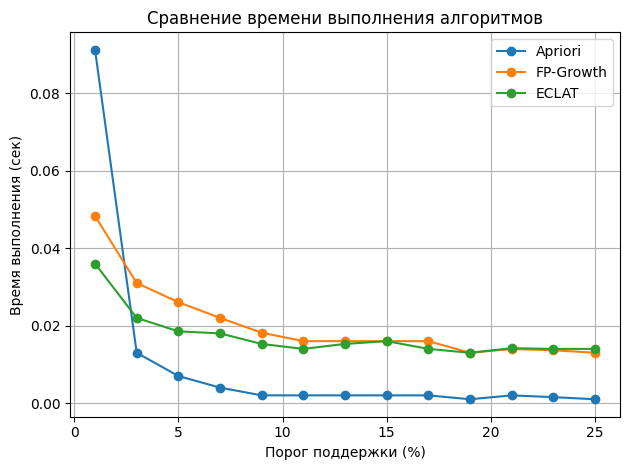

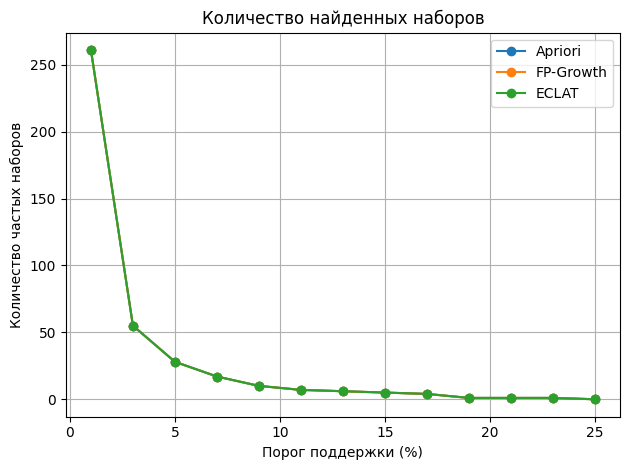

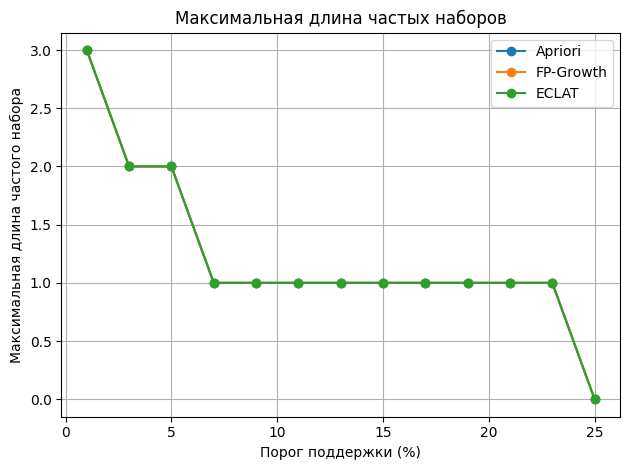

In [196]:
# plt.figure(figsize=(8, 8))

# График сравнения времени выполнения
# plt.subplot(3, 1, 1)
for alg in algorithms:
    plt.plot(support_values, execution_times[alg], marker="o", label=alg)
plt.xlabel('Порог поддержки (%)')
plt.ylabel('Время выполнения (сек)')
plt.title('Сравнение времени выполнения алгоритмов')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("execution_time.png", dpi=300)
plt.show()

# График общего количества частых наборов
# plt.subplot(3, 1, 2)
for alg in algorithms:
    plt.plot(support_values, itemset_counts[alg], marker="o", label=alg)
plt.xlabel('Порог поддержки (%)')
plt.ylabel('Количество частых наборов')
plt.title('Количество найденных наборов')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("itemsets.png", dpi=300)
plt.show()

# График максимальной длины частого набора
# plt.subplot(3, 1, 3)
for alg in algorithms:
    plt.plot(support_values, max_lengths[alg], marker="o", label=alg)
plt.xlabel('Порог поддержки (%)')
plt.ylabel('Максимальная длина частого набора')
plt.title('Максимальная длина частых наборов')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("max_frequent_itemsets.png", dpi=300)
plt.show()
# plt.tight_layout()
# plt.show()

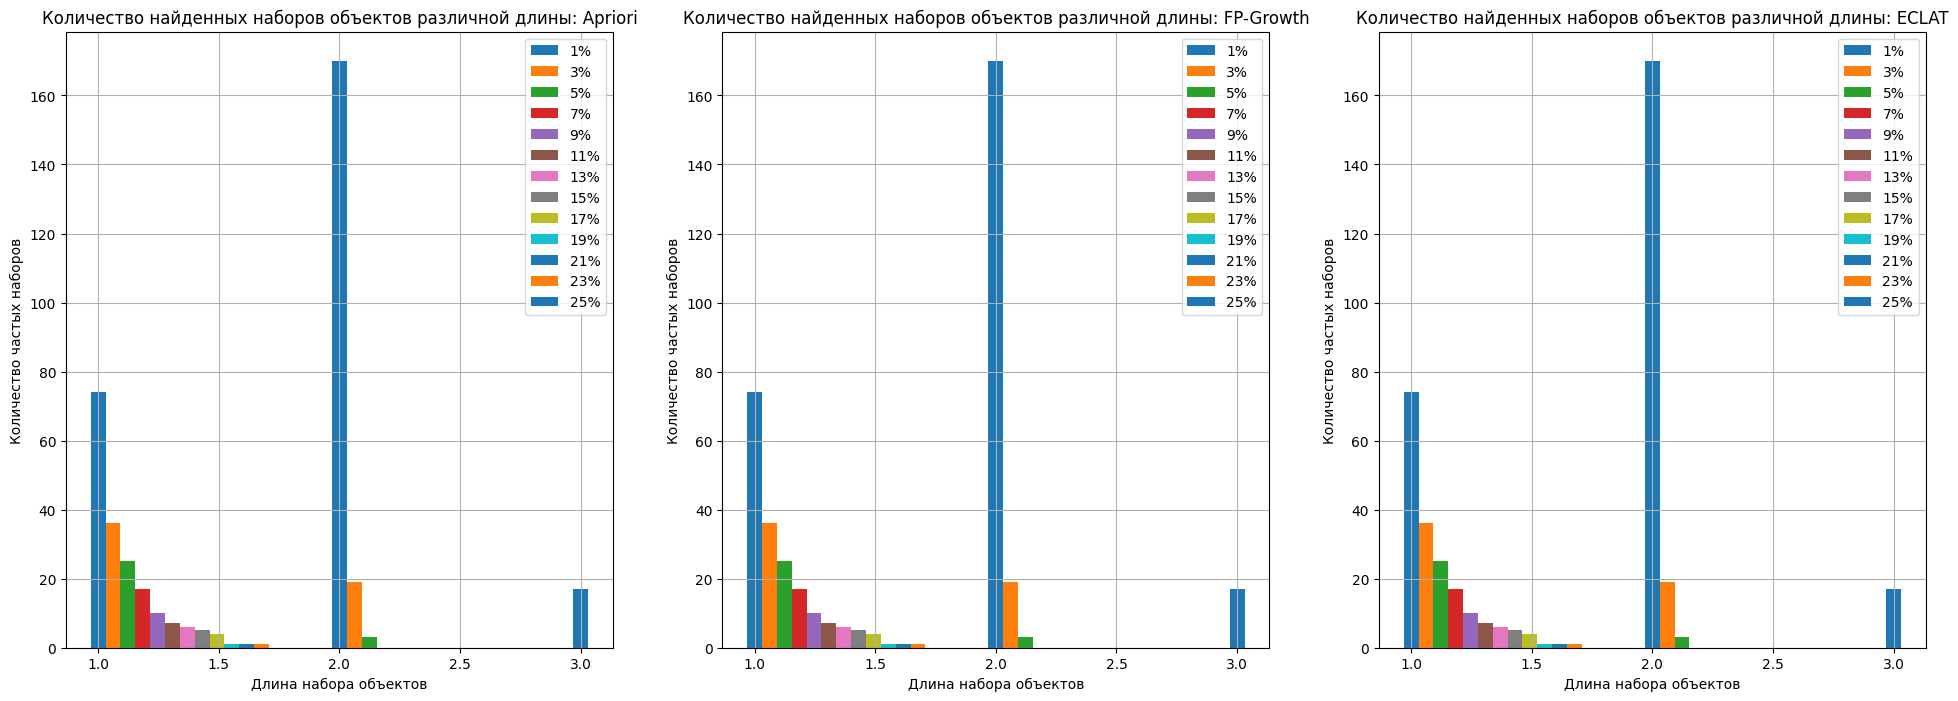

In [204]:
# График количества частых наборов объектов различной длины (гистограмма)
# plt.subplot(2, 2, 4)
width = 0.8 / len(support_values)
fig_counter = 1

plt.figure(figsize=(24, 8))
for alg in length_distributions.keys():
    plt.subplot(1, 3, fig_counter)
    # plt.figure(figsize=(8, 6))
    dist = length_distributions[alg]
    for i, support in enumerate(support_values):
        lengths, counts = list(dist[i].keys()), list(dist[i].values())
        plt.bar([l + i*width for l in lengths], counts, width=width, label=f'{support}%')
            
    plt.xlabel('Длина набора объектов')
    plt.ylabel('Количество частых наборов')
    plt.title(f'Количество найденных наборов объектов различной длины: {alg}')
    plt.legend()
    plt.grid(True)
    # plt.savefig(f"different_lengths_{fig_counter}.png", dpi=300)
    fig_counter += 1
plt.show()

In [195]:
support_value = 0.01  # 1%

print(f"Сравнение алгоритмов при минимальном пороге поддержки {support_value*100}%:")

# Apriori
apriori_detailed, apriori_time = run_apriori(df_encoded, min_support=support_value)

# FP-Growth
fpgrowth_detailed, fpgrowth_time = run_fpgrowth(df_encoded, min_support=support_value)

# ECLAT
eclat_detailed, eclat_time = run_eclat(df_eclat, min_support=support_value)

print(f"Apriori: {len(apriori_detailed)} наборов, {apriori_time:.4f} сек")
print(f"FP-Growth: {len(fpgrowth_detailed)} наборов, {fpgrowth_time:.4f} сек")
print(f"ECLAT: {len(eclat_detailed)} наборов, {eclat_time:.4f} сек")

print("\nЧастые наборы, полученные в результате выполнения Apriori, с фильтрацией количества <= 7")
apriori_detailed[
    apriori_detailed["itemsets"].apply(lambda x: len(x) <= 7)
]

Сравнение алгоритмов при минимальном пороге поддержки 1.0%:
Frequent patterns were generated successfully using ECLAT algorithm
Apriori: 261 наборов, 0.0950 сек
FP-Growth: 261 наборов, 0.0502 сек
ECLAT: 261 наборов, 0.0370 сек

Частые наборы, полученные в результате выполнения Apriori, с фильтрацией количества <= 7


,support,itemsets
31,0.238368,"(минеральная вода,)"
26,0.187975,"(макароны,)"
73,0.179709,"(яйца,)"
20,0.170911,"(картофель-фри,)"
69,0.163845,"(шоколад,)"
...,...,...
124,0.010265,"(торт, замороженные овощи)"
210,0.010265,"(хлопья, минеральная вода)"
248,0.010132,"(яйца, говяжий фарш, минеральная вода)"
120,0.010132,"(низкокалорийный йогурт, замороженные овощи)"
